In [1]:
import os

import numpy as np
import pandas as pd
from features import *
import matplotlib.pyplot as plt
import ast
import seaborn as sns

In [2]:
def complete_dict(list_dataframe, cleaness):
    if cleaness == 0:
        path = "../Data/train/with_label/clean"
    elif cleaness == 1:
        path = "../Data/train/with_label/dirty"
    else:
        path = "../Data/train/with_label/very_dirty"
    for e in os.scandir(path):
        if e.is_file():
            dict = {}
            path = e.path
            dict['name'] = e.name
            features_img = extract_features(path)
            for key in features_img.keys():
                dict[key] = features_img[key]
            if cleaness == 0 :
                dict['class'] = 'clean'
            elif cleaness == 1:
                dict['class'] = 'dirty'
            else:
                dict['class'] = 'very_dirty'
            list_dataframe.append(dict)

In [3]:
def get_dataframe() -> list:
    list_dataframe = []

    complete_dict(list_dataframe, 0)    
    complete_dict(list_dataframe, 1)
    complete_dict(list_dataframe, 2)

    return list_dataframe

In [4]:
list_df = get_dataframe()
df = pd.DataFrame(list_df)
df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']] = df[['file_size', 'mean_r', 'mean_g', 'mean_b', 'brightness', 'saturation', 'edge_density', 'contraste_global', 'edge_density_V2']].astype(float)
df[['image_width', 'image_height', 'contraste_maximal']] = df[['image_width', 'image_height', 'contraste_maximal']].astype(int)

In [5]:
df

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,saturation,hist_rgb,hist_luminance,edge_density,edge_density_V2,class
0,train_clean_img_001.jpeg,69.07,600,600,122.39,127.30,121.97,125.22429,255,56.431538,29.08,"{""red"": [110, 28, 27, 20, 38, 36, 58, 58, 73, ...","[1, 33, 27, 15, 22, 21, 28, 35, 37, 45, 41, 61...",0.1123,52889.0,clean
1,train_clean_img_002.jpeg,35.45,600,529,106.65,114.13,105.04,110.85722,254,52.839565,35.08,"{""red"": [8, 3, 1, 5, 2, 7, 12, 31, 34, 36, 61,...","[0, 1, 3, 1, 9, 4, 13, 18, 31, 56, 82, 84, 82,...",0.0545,23010.0,clean
2,train_clean_img_003.jpeg,57.77,600,688,122.54,121.58,120.12,121.70060,255,39.285750,44.79,"{""red"": [52, 27, 31, 31, 43, 41, 58, 51, 60, 5...","[3, 13, 10, 18, 36, 33, 41, 48, 59, 75, 61, 67...",0.0541,52980.0,clean
3,train_clean_img_004.jpeg,47.19,600,600,130.69,132.25,129.66,131.48830,254,44.082533,17.20,"{""red"": [8, 1, 3, 7, 12, 6, 14, 12, 23, 23, 25...","[0, 4, 2, 4, 2, 3, 9, 13, 15, 20, 22, 30, 41, ...",0.0677,37542.0,clean
4,train_clean_img_005.jpeg,192.64,1382,1496,111.27,109.90,101.31,109.33037,255,48.528542,40.16,"{""red"": [65, 40, 38, 86, 154, 289, 469, 834, 1...","[11, 44, 69, 108, 240, 408, 844, 1573, 2059, 2...",0.0330,112613.0,clean
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
151,train_no_label_img_512.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
152,train_no_label_img_515.jpeg,276.22,600,338,133.58,128.67,120.25,129.17821,255,70.702186,65.50,"{""red"": [61, 26, 27, 20, 32, 55, 65, 105, 167,...","[4, 2, 4, 8, 12, 16, 34, 65, 138, 164, 225, 26...",0.1471,41776.0,very_dirty
153,train_no_label_img_517.jpeg,1547.53,1920,2560,81.42,85.96,76.49,83.52296,253,52.977648,57.18,"{""red"": [54, 28, 67, 191, 712, 2726, 9069, 200...","[0, 0, 1, 2, 72, 1151, 6848, 17708, 25976, 258...",0.0186,111357.0,very_dirty
154,train_no_label_img_521.jpeg,31.21,600,345,112.12,107.95,101.57,108.46951,254,56.065651,42.62,"{""red"": [26, 42, 62, 116, 144, 268, 365, 500, ...","[12, 32, 43, 90, 138, 248, 378, 495, 634, 713,...",0.0440,28214.0,very_dirty


Get the max and min of every color of the histogramme

In [6]:
df['max_r'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['max_g'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['max_b'] = df.apply(lambda row : max(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

df['min_r'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['red']), axis =1)
df['min_g'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['green']), axis =1)
df['min_b'] = df.apply(lambda row : min(ast.literal_eval(row['hist_rgb'])['blue']), axis =1)

Get index of max

In [7]:
df['index_max_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['max_r']), axis =1)
df['index_max_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['max_g']), axis =1)
df['index_max_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['max_b']), axis =1)

df['index_min_r'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['red'].index(row['min_r']), axis =1)
df['index_min_g'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['green'].index(row['min_g']), axis =1)
df['index_min_b'] = df.apply(lambda row : ast.literal_eval(row['hist_rgb'])['blue'].index(row['min_b']), axis =1)

Get the max and min of the luminance

In [8]:
df['max_lum'] = df.apply(lambda row : max(ast.literal_eval(row['hist_luminance'])), axis =1)
df['min_lum'] = df.apply(lambda row : min(ast.literal_eval(row['hist_luminance'])), axis =1)

In [9]:
df['index_max_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['max_lum']), axis =1)
df['index_min_lum'] = df.apply(lambda row : ast.literal_eval(row['hist_luminance']).index(row['min_lum']), axis =1)

Get the difference and sum of the averages

In [10]:
df['sum_avg'] = df['mean_r'] + df['mean_g'] + df['mean_b']
df['sum_diff_avg'] = abs(df['mean_r'] - df['mean_g']) + abs(df['mean_r'] - df['mean_b']) + abs(df['mean_b'] - df['mean_g'])

In [11]:
def get_whites_from_hist_v2(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])

    diff =abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0)[200:])
    return whites

In [12]:
def get_whites_from_hist(hist):
    red = np.array(hist['red'])
    green = np.array(hist['green'])
    blue = np.array(hist['blue'])
    diff = abs(red -green) + abs(red - blue) + abs(green-blue)
    mean = (red + green + blue)/3
    whites = sum(((mean - diff)>0))
    print(whites)
    return whites


get_whites_from_hist_v2(ast.literal_eval(df.iloc[2]['hist_rgb']))

np.int64(7)

In [13]:
df['quantity_of_whites'] = df.apply(lambda row : get_whites_from_hist(ast.literal_eval(row['hist_rgb'])), axis =1)
#df['quantity of whites'] = df.apply(lambda row : get_whites_from_hist_v2(ast.literal_eval(row['hist_rgb'])), axis =1)


201
120
57
209
76
154
197
177
189
110
124
132
168
99
113
94
177
41
144
150
192
129
120
59
125
70
130
51
182
209
87
138
124
91
93
89
70
164
116
177
120
123
124
174
170
96
178
126
149
157
121
199
153
154
173
121
210
103
139
54
175
159
167
119
118
107
187
108
152
208
73
227
143
103
135
222
188
131
215
211
185
120
237
127
94
159
183
67
88
190
176
24
162
96
76
65
167
10
3
84
87
121
142
82
54
142
37
84
66
130
110
169
85
246
206
185
146
183
242
226
101
148
133
237
184
123
201
187
181
139
127
113
135
215
223
230
108
251
164
211
179
211
219
246
186
222
191
200
146
226
188
130
130
169
185
133


In [14]:
column_to_normalize = df.select_dtypes(include=['float', 'int']).columns.values.tolist()

from sklearn import preprocessing

x = df[column_to_normalize].values #returns a numpy array
min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(x)
df[column_to_normalize] = pd.DataFrame(x_scaled)
# df [column_to_normalize] = (df[column_to_normalize]-df[column_to_normalize].mean())/df[column_to_normalize].std()

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class'] = le.fit_transform(df['class'])

In [16]:
df.head(20)

,name,file_size,image_width,image_height,mean_r,mean_g,mean_b,brightness,contraste_maximal,contraste_global,...,index_min_r,index_min_g,index_min_b,max_lum,min_lum,index_max_lum,index_min_lum,sum_avg,sum_diff_avg,quantity_of_whites
0,train_clean_img_001.jpeg,0.009256,0.107412,0.146974,0.581784,0.679375,0.701068,0.655370,1.000000,0.504376,...,0.996063,0.000000,0.003937,0.032716,0.000363,0.466667,0.000000,0.658153,0.076854,0.798387
1,train_clean_img_002.jpeg,0.004043,0.107412,0.124240,0.431664,0.565772,0.570091,0.529494,0.972973,0.441385,...,0.007874,0.003937,0.003937,0.020817,0.000000,1.000000,0.000000,0.527197,0.133404,0.471774
2,train_clean_img_003.jpeg,0.007504,0.107412,0.175152,0.583214,0.630035,0.686755,0.624498,1.000000,0.203700,...,0.948819,0.913386,0.960630,0.018678,0.000363,0.576471,0.913725,0.636956,0.033088,0.217742
3,train_clean_img_004.jpeg,0.005863,0.107412,0.146974,0.660944,0.722074,0.760560,0.710252,0.972973,0.287818,...,0.003937,0.003937,1.000000,0.037180,0.000000,0.752941,0.000000,0.717975,0.035644,0.830645
4,train_clean_img_005.jpeg,0.028418,0.310793,0.433878,0.475727,0.529285,0.541235,0.516117,1.000000,0.365786,...,0.007874,0.003937,0.003937,0.138844,0.003990,0.313725,0.000000,0.517655,0.146488,0.294355
5,train_clean_img_006.jpeg,0.009582,0.107412,0.146974,0.491273,0.592340,0.578447,0.562786,1.000000,0.411012,...,0.984252,0.984252,0.992126,0.018047,0.001088,0.513725,0.980392,0.556936,0.163483,0.608871
6,train_clean_img_007.jpeg,0.007895,0.107412,0.146974,0.488794,0.570603,0.596008,0.551412,1.000000,0.427111,...,0.996063,0.984252,0.988189,0.018191,0.002176,0.486275,0.992157,0.555479,0.091442,0.782258
7,train_clean_img_008.jpeg,0.009182,0.107412,0.146974,0.536481,0.591650,0.656661,0.584890,1.000000,0.387107,...,0.003937,0.992126,1.000000,0.013373,0.000725,0.407843,0.000000,0.599132,0.017897,0.701613
8,train_clean_img_009.jpeg,0.009651,0.107412,0.146974,0.504149,0.562236,0.601578,0.551360,1.000000,0.374377,...,0.007874,0.007874,0.003937,0.020849,0.000725,0.419608,0.000000,0.559365,0.073996,0.750000
9,train_clean_img_010.jpeg,0.010655,0.107412,0.146974,0.536671,0.622013,0.683042,0.606451,1.000000,0.332509,...,0.003937,0.007874,0.992126,0.022596,0.000725,0.584314,0.000000,0.618986,0.041660,0.431452


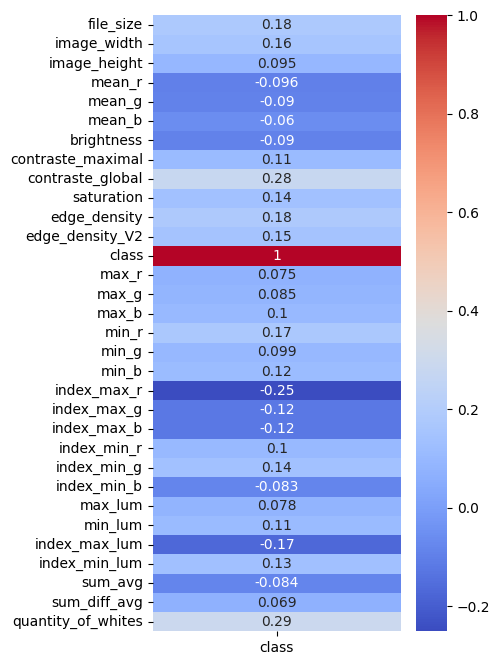

In [17]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(4, 8))
sns.heatmap(corr_matrix[['class']], cmap='coolwarm', annot = True)
plt.show()

We tested the correlation matrix with the initial 40 images and the correlation matrix with additional images classified by hand (132 images in total)

Test with 20 images from each side, we keep >0.15 and <-0.15
- file_size
- image_width
- image_height
- mean_r
- mean_g
- brightness
- contraste_global
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_avg
- quantities_of_whites

test with 66 images from each side, we keep >0.1 and <0.1
- file_size
- image_width
- image_height
- edge_density_V2
- max_r
- max_g
- max_b
- min_r
- min_g
- min_b
- index_max_r
- index_max_g
- index_min_b
- max_lum
- min_lum
- index_max_lum
- index_min_lum
- sum_diff_avg

We can see that some values are still here and some changed. We will do some tests and check if some values should not be kept. In the mean time, we will keep the variables from the test with the biggest number

In [18]:
df_clean = df[df['class'] == 0]
df_dirty = df[df['class'] == 1]

In [39]:
weights_test = {"mean_r":0, "mean_g":0, "brightness":0, "contraste_global":0.42, "edge_density_V2":0.3, "max_r":0, "max_g":0, "max_b":0, "min_r":0.55, "min_g":0, "min_b":0.45, "index_max_r":0, "index_max_g":0, "max_lum":0, "min_lum":0.33, "index_max_lum":0, "index_min_lum":0, "sum_avg":0, "quantity_of_whites":0.49}

In [34]:
thresholds_test = [50, 75]

In [36]:
def score_to_class(score, thresholds):
    if score < thresholds[0]:
        clean_class = "clean"
    elif thresholds[0] <= score <= thresholds[1]:
        clean_class = "dirty"
    else:
        clean_class = "very_dirty"
    return clean_class

def compute_score(img_features, weights):
    cleaness_score = sum([img_features[k]*v for k,v in weights.items()])
    return cleaness_score*100

In [37]:
def predict(df, weights, thresholds):
    y_pred = []
    for index, row in df.iterrows():
        y_pred.append(score_to_class(compute_score(row, weights), thresholds))
    return y_pred

In [40]:
y_pred_str = predict(df, weights_test, thresholds_test)
y_pred = le.transform(y_pred_str)

Accuracy :  0.46794871794871795
Rapport de classification:
               precision    recall  f1-score   support

           0       0.53      0.61      0.57        66
           1       0.38      0.35      0.37        66
           2       0.48      0.42      0.44        24

    accuracy                           0.47       156
   macro avg       0.46      0.46      0.46       156
weighted avg       0.46      0.47      0.46       156



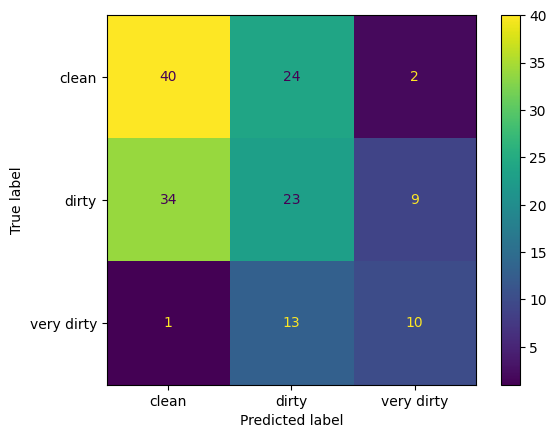

In [25]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
y_true = df['class']

conf_matrix = confusion_matrix(y_true, y_pred)
plt = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=['clean', 'dirty', 'very dirty'])
plt.plot()

print('Accuracy : ', accuracy_score(y_true, y_pred))
# print("Precision:", precision_score(y_true, y_pred))
# print("Recall:", recall_score(y_true, y_pred))
# print("F1 Score:", f1_score(y_true, y_pred))
print("Rapport de classification:\n", classification_report(y_true, y_pred))

In [47]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform

weights_base = ["mean_r", "mean_g", "brightness", "contraste_global", "edge_density_V2", "max_r", "max_g", "max_b", "min_r", "min_g", "min_b", "index_max_r", "index_max_g", "max_lum", "min_lum", "index_max_lum", "index_min_lum", "sum_avg", "quantity_of_whites"]

param_distributions = {k: uniform(0.0, 1.0) for k in weights_base}
n_iter = 10000
sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=2)

max_accuracy = 0
save_weights = None

for sample in sampler:
    y_pred_str = predict(df, sample, thresholds_test)
    y_pred = le.transform(y_pred_str)
    accuracy = accuracy_score(y_true, y_pred)
    if accuracy>max_accuracy:
        save_weights = sample
        max_accuracy = accuracy

print(max_accuracy)

0.3076923076923077


Create random population

In [82]:
import time

class Element :
    def __init__(self):
        weights_base = ["mean_r", "mean_g", "brightness", "contraste_global", "edge_density_V2", "max_r", "max_g", "max_b", "min_r", "min_g", "min_b", "index_max_r", "index_max_g", "max_lum", "min_lum", "index_max_lum", "index_min_lum", "sum_avg", "quantity_of_whites"]

        weights_values = np.random.rand(19)
        self.weights = {}
        for i in range(len(weights_base)):
            self.weights[weights_base[i]] = weights_values[i]


        self.threshold = np.random.rand(2)

    def get_accuracy(self):
        y_pred_str = predict(df, weights_test, thresholds_test)
        y_pred = le.transform(y_pred_str)
        return accuracy_score(y_true, y_pred)

def create_pop(number_element):
    pop = []
    for i in range(number_element):
        pop.append(Element())
    return pop

def get_best(pop):
    sorted_pop = sorted(pop, key=lambda elem: elem.get_accuracy())
    return pop[:500]

def get_child(element1, element2):
    pass

def mutation(element):
    return element

In [83]:
population = create_pop(10)
new_pop = get_best(population)


In [56]:
from sklearn.model_selection import ParameterSampler
from scipy.stats import uniform

weights_base = ["mean_r", "mean_g", "brightness", "contraste_global", "edge_density_V2", "max_r", "max_g", "max_b", "min_r", "min_g", "min_b", "index_max_r", "index_max_g", "max_lum", "min_lum", "index_max_lum", "index_min_lum", "sum_avg", "quantity_of_whites"]

param_distributions = {k: uniform(0.0, 1.0) for k in weights_base}
n_iter = 1
sampler = ParameterSampler(param_distributions, n_iter=n_iter, random_state=2)

thresholds = np.random.rand(500, 2)

for sample in sampler:
    print(sample)

{'brightness': np.float64(0.43599490214200376), 'contraste_global': np.float64(0.025926231827891333), 'edge_density_V2': np.float64(0.5496624778787091), 'index_max_g': np.float64(0.4353223926182769), 'index_max_lum': np.float64(0.42036780208748903), 'index_max_r': np.float64(0.3303348210038741), 'index_min_lum': np.float64(0.2046486340378425), 'max_b': np.float64(0.6192709663506637), 'max_g': np.float64(0.29965467367452314), 'max_lum': np.float64(0.26682727510286663), 'max_r': np.float64(0.6211338327692949), 'mean_g': np.float64(0.5291420942770391), 'mean_r': np.float64(0.13457994534493356), 'min_b': np.float64(0.5135781212657464), 'min_g': np.float64(0.18443986564691528), 'min_lum': np.float64(0.7853351478166735), 'min_r': np.float64(0.8539752926394888), 'quantity_of_whites': np.float64(0.4942368373819278), 'sum_avg': np.float64(0.846561485357468)}


selection des 250 meilleurs

In [86]:

np.random.rand(2)

1